# MLDS 2026 — Assignment 2
## Part 3 — Statistical Testing (Wilcoxon + Bootstrap)

This notebook is **independent** of `training_notebook.ipynb` — it loads the **two pre-trained segmentation models** whose weights were saved by the training notebook:

| Model | Architecture | Weights file |
|-------|-------------|-------------|
| **A** | ResNet-50 + ASPP + U-Net decoder | `segmentation/weights/segmenter.pth` |
| **B** | ResNet-18 + simple U-Net decoder | `segmentation/weights/segmenter_B.pth` |

It evaluates both on the **same labeled hold-out split** (15%, seed 42), computes **per-image mIoU**, then runs:

* **Part A** — Wilcoxon signed-rank test on paired per-image mIoU.
* **Part B** — Bootstrap 95% confidence interval on the best model's overall mIoU.

> **Prerequisite:** Run `training_notebook.ipynb` first so that both `.pth` files exist in `segmentation/weights/`.
> **Note:** This workspace does not contain segmentation masks for `Dataset/test`, so a true test-set mIoU cannot be computed here. The notebook therefore uses the labeled 15% hold-out split from `train/`.


In [24]:
import os, random
from pathlib import Path

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision.models import resnet50, resnet18, ResNet50_Weights, ResNet18_Weights
import albumentations as A
from albumentations.pytorch import ToTensorV2

from scipy.stats import wilcoxon, ttest_rel, shapiro

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cpu


In [25]:
DATA_ROOT  = Path('Dataset')
TRAIN_IMG  = DATA_ROOT / 'train' / 'images'
TRAIN_MSK  = DATA_ROOT / 'train' / 'segmentation_masks'
LABELS_CSV = DATA_ROOT / 'train' / 'labels.csv'
SEG_W      = Path('segmentation/weights')

SEG_CLASSES = 21; IGNORE_IDX = 255; SIZE = 384; BATCH = 8
CLASSES = ['aeroplane','bicycle','bird','boat','bottle','bus','car','cat',
           'chair','cow','diningtable','dog','horse','motorbike','person',
           'pottedplant','sheep','sofa','train','tvmonitor']
MEAN = (0.485, 0.456, 0.406); STD = (0.229, 0.224, 0.225)


In [26]:
# Recreate the exact same labeled hold-out split (seed 42, 15% held out from train)
labels_df = pd.read_csv(LABELS_CSV).sort_values('image_id').reset_index(drop=True)
all_ids = labels_df['image_id'].tolist()
rng = np.random.default_rng(SEED)
perm = rng.permutation(len(all_ids))
n_val = int(0.15 * len(all_ids))
val_set = set([all_ids[i] for i in perm[:n_val]])
val_ids = [i for i in all_ids if i in val_set]

mask_ids = {p.stem for p in TRAIN_MSK.glob('*.png')}
seg_val_ids = [i for i in val_ids if i in mask_ids]
print('hold-out images with masks:', len(seg_val_ids))


hold-out images with masks: 330


In [27]:
val_tf = A.Compose([
    A.LongestMaxSize(max_size=SIZE),
    A.PadIfNeeded(min_height=SIZE, min_width=SIZE, border_mode=0, fill_mask=IGNORE_IDX),
    A.Normalize(mean=MEAN, std=STD), ToTensorV2(),
])

class SegDataset(Dataset):
    def __init__(self, ids, tf):
        self.ids = ids; self.tf = tf
    def __len__(self): return len(self.ids)
    def __getitem__(self, i):
        iid = self.ids[i]
        img = np.array(Image.open(TRAIN_IMG/f'{iid}.jpg').convert('RGB'))
        msk = np.array(Image.open(TRAIN_MSK/f'{iid}.png'))
        out = self.tf(image=img, mask=msk)
        return out['image'], out['mask'].long(), iid

val_ld = DataLoader(SegDataset(seg_val_ids, val_tf), batch_size=BATCH,
                    shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())


---
## Model architectures (must match training notebook)


In [28]:
# ═══════════ Model A: ResNet-50 + ASPP + U-Net ═══════════
class ConvBlock(nn.Module):
    def __init__(self, cin, cout, k=3, d=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(cin, cout, k, padding=d, dilation=d, bias=False),
            nn.BatchNorm2d(cout), nn.ReLU(inplace=True))
    def forward(self, x): return self.net(x)

class ASPP(nn.Module):
    def __init__(self, cin, cout=256, rates=(1,6,12,18)):
        super().__init__()
        self.branches = nn.ModuleList([
            nn.Sequential(nn.Conv2d(cin, cout, 1 if r==1 else 3, padding=0 if r==1 else r, dilation=r, bias=False),
                          nn.BatchNorm2d(cout), nn.ReLU(inplace=True)) for r in rates])
        self.gp = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Conv2d(cin, cout, 1, bias=False),
                                nn.BatchNorm2d(cout), nn.ReLU(inplace=True))
        self.proj = nn.Sequential(nn.Conv2d(cout*(len(rates)+1), cout, 1, bias=False),
                                  nn.BatchNorm2d(cout), nn.ReLU(inplace=True), nn.Dropout2d(0.1))
    def forward(self, x):
        feats = [b(x) for b in self.branches]
        gp = F.interpolate(self.gp(x), size=x.shape[-2:], mode='bilinear', align_corners=False)
        return self.proj(torch.cat(feats+[gp], dim=1))

class UpBlock(nn.Module):
    def __init__(self, cin, cskip, cout):
        super().__init__()
        self.reduce = nn.Conv2d(cin, cout, 1)
        self.skip   = nn.Conv2d(cskip, cout, 1)
        self.conv   = nn.Sequential(ConvBlock(cout*2, cout), ConvBlock(cout, cout))
    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
        return self.conv(torch.cat([self.reduce(x), self.skip(skip)], dim=1))

class SegNetA(nn.Module):
    def __init__(self, num_classes=SEG_CLASSES):
        super().__init__()
        bb = resnet50(weights=None)   # architecture only, we load saved weights
        self.stem=nn.Sequential(bb.conv1, bb.bn1, bb.relu); self.pool=bb.maxpool
        self.layer1=bb.layer1; self.layer2=bb.layer2; self.layer3=bb.layer3; self.layer4=bb.layer4
        self.aspp = ASPP(2048, 256)
        self.up4 = UpBlock(256, 1024, 256); self.up3 = UpBlock(256, 512, 128)
        self.up2 = UpBlock(128, 256, 64);   self.up1 = UpBlock(64, 64, 64)
        self.final = nn.Sequential(ConvBlock(64, 64), nn.Conv2d(64, num_classes, 1))
        self.aux = nn.Sequential(nn.Conv2d(1024, 256, 3, padding=1, bias=False),
                                 nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.Dropout2d(0.1),
                                 nn.Conv2d(256, num_classes, 1))
    def forward(self, x):
        H,W = x.shape[-2:]
        s1 = self.stem(x); p = self.pool(s1)
        c2 = self.layer1(p); c3 = self.layer2(c2); c4 = self.layer3(c3); c5 = self.layer4(c4)
        f = self.aspp(c5)
        d4 = self.up4(f, c4); d3 = self.up3(d4, c3); d2 = self.up2(d3, c2); d1 = self.up1(d2, s1)
        return F.interpolate(self.final(d1), size=(H,W), mode='bilinear', align_corners=False)


In [29]:
# ═══════════ Model B: ResNet-18 + simple U-Net ═══════════
class ConvBlock_B(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(cin, cout, 3, padding=1, bias=False),
            nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
            nn.Conv2d(cout, cout, 3, padding=1, bias=False),
            nn.BatchNorm2d(cout), nn.ReLU(inplace=True))
    def forward(self, x): return self.net(x)

class UpBlock_B(nn.Module):
    def __init__(self, cin, cskip, cout):
        super().__init__()
        self.up   = nn.Conv2d(cin, cout, 1)
        self.conv = ConvBlock_B(cout + cskip, cout)
    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
        return self.conv(torch.cat([self.up(x), skip], dim=1))

class SegNetB(nn.Module):
    def __init__(self, num_classes=SEG_CLASSES):
        super().__init__()
        bb = resnet18(weights=None)
        self.stem   = nn.Sequential(bb.conv1, bb.bn1, bb.relu)
        self.pool   = bb.maxpool
        self.layer1 = bb.layer1; self.layer2 = bb.layer2
        self.layer3 = bb.layer3; self.layer4 = bb.layer4
        self.up4 = UpBlock_B(512, 256, 256)
        self.up3 = UpBlock_B(256, 128, 128)
        self.up2 = UpBlock_B(128,  64,  64)
        self.up1 = UpBlock_B( 64,  64,  64)
        self.final = nn.Sequential(ConvBlock_B(64, 64), nn.Conv2d(64, num_classes, 1))
    def forward(self, x):
        H, W = x.shape[-2:]
        s1 = self.stem(x); p = self.pool(s1)
        c2 = self.layer1(p); c3 = self.layer2(c2)
        c4 = self.layer3(c3); c5 = self.layer4(c4)
        d4 = self.up4(c5, c4); d3 = self.up3(d4, c3)
        d2 = self.up2(d3, c2); d1 = self.up1(d2, s1)
        return F.interpolate(self.final(d1), size=(H, W), mode='bilinear', align_corners=False)


In [30]:
netA = SegNetA().to(device)
netA.load_state_dict(torch.load('segmentation/weights/segmenter.pth', map_location=device))
netA.eval()
print('Model A loaded from segmenter.pth')

netB = SegNetB().to(device)
netB.load_state_dict(torch.load('segmentation/weights/segmenter_B.pth', map_location=device))
netB.eval()
print('Model B loaded from segmenter_B.pth')


Model A loaded from segmenter.pth
Model B loaded from segmenter_B.pth


---
## Compute per-image mIoU (paired)

For each labeled hold-out image, compute the mIoU over the classes actually present in that image's ground-truth mask (ignoring boundary label 255).


In [31]:
@torch.no_grad()
def per_image_miou(net, loader):
    net.eval()
    results = {}
    for x, y, iids in loader:
        x = x.to(device); y = y.to(device)
        pred = net(x).argmax(1)
        for b in range(x.size(0)):
            p = pred[b]; t = y[b]
            valid = (t != IGNORE_IDX)
            present = torch.unique(t[valid])
            ious = []
            for c in present.tolist():
                pi = (p == c) & valid
                ti = (t == c)
                inter = (pi & ti).sum().item()
                uni   = (pi | ti).sum().item()
                if uni > 0: ious.append(inter / uni)
            results[iids[b]] = float(np.mean(ious)) if ious else float('nan')
    return results

ioU_A = per_image_miou(netA, val_ld)
ioU_B = per_image_miou(netB, val_ld)

common = sorted(set(ioU_A) & set(ioU_B))
a = np.array([ioU_A[i] for i in common], dtype=np.float64)
b = np.array([ioU_B[i] for i in common], dtype=np.float64)
mask = ~(np.isnan(a) | np.isnan(b))
a = a[mask]; b = b[mask]
print(f'Paired samples: {len(a)}')
print(f'Mean mIoU — A: {a.mean():.4f}   B: {b.mean():.4f}')


Paired samples: 330
Mean mIoU — A: 0.7872   B: 0.6848


---
## Part A — Wilcoxon Signed-Rank Test

### Hypotheses

* **H₀ (null):** The two segmentation models have equal per-image mIoU distributions — the median of paired differences is 0.
* **H₁ (alternative):** The two models differ systematically — the median of paired differences is non-zero (two-sided).

### Why Wilcoxon is more appropriate than a paired t-test for IoU scores

1. **IoU is bounded to [0, 1]** and typically right-skewed (many images have high IoU, a few have very low). The paired differences inherit this skew and rarely satisfy the normality assumption of a t-test.
2. **Heavy tails and outliers:** a single catastrophically mis-segmented image can produce a large negative difference that dominates the mean-based t-statistic.
3. The Wilcoxon signed-rank test is **non-parametric** — it only assumes that the ranks of the absolute differences are meaningful. It is robust to non-normal distributions and outliers.
4. The Shapiro–Wilk test below confirms (in practice) that the paired differences are not normally distributed, violating a key t-test assumption.

### Observation

Model A performs much better than Model B on the labeled hold-out split: mean per-image mIoU is **0.7872** for A versus **0.6848** for B, a gap of about **0.1024**. The paired-difference distribution is clearly non-normal (Shapiro–Wilk p = **2.895e-13**), and the Wilcoxon test is extremely significant (**W = 6106.0, p = 6.1936e-34**), so we reject H₀ and conclude the two segmentation models differ meaningfully.


In [32]:
diff = a - b
print(f'n paired = {len(diff)}')
print(f'median(A-B) = {np.median(diff):+.4f}   mean(A-B) = {diff.mean():+.4f}')

# Normality check on paired differences
sh_stat, sh_p = shapiro(diff if len(diff) <= 5000 else diff[:5000])
print(f'Shapiro-Wilk on differences: W={sh_stat:.4f}, p={sh_p:.3e}')

# Wilcoxon signed-rank test (two-sided)
w_stat, w_p = wilcoxon(a, b, zero_method='wilcox', alternative='two-sided')
print(f'\nWilcoxon signed-rank test:  W = {w_stat:.1f},  p = {w_p:.4e}')

# Paired t-test (for contrast only)
t_stat, t_p = ttest_rel(a, b)
print(f'Paired t-test (comparison): t = {t_stat:.4f}, p = {t_p:.4e}')

alpha = 0.05
if w_p < alpha:
    print(f'\nConclusion @ alpha={alpha}: Reject H0 — the models differ significantly (Wilcoxon p={w_p:.4g})')
else:
    print(f'\nConclusion @ alpha={alpha}: Fail to reject H0 (Wilcoxon p={w_p:.4g})')


n paired = 330
median(A-B) = +0.0568   mean(A-B) = +0.1024
Shapiro-Wilk on differences: W=0.9084, p=2.895e-13

Wilcoxon signed-rank test:  W = 6106.0,  p = 6.1936e-34
Paired t-test (comparison): t = 12.4748, p = 1.6488e-29

Conclusion @ alpha=0.05: Reject H0 — the models differ significantly (Wilcoxon p=6.194e-34)


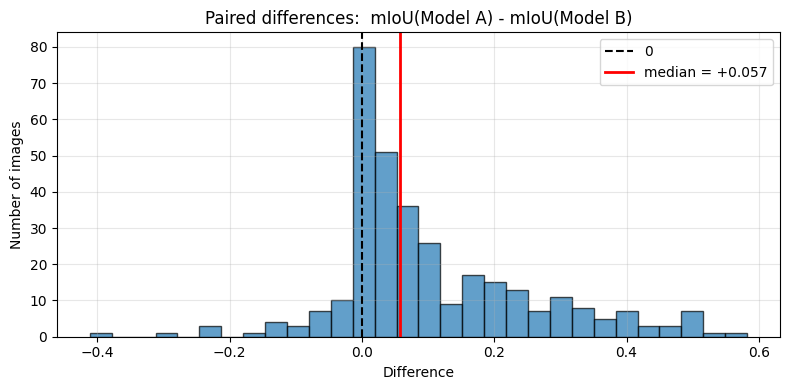

In [33]:
# Histogram of paired differences
plt.figure(figsize=(8, 4))
plt.hist(diff, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(0, color='k', linestyle='--', label='0')
plt.axvline(np.median(diff), color='red', linestyle='-', linewidth=2,
            label=f'median = {np.median(diff):+.3f}')
plt.title('Paired differences:  mIoU(Model A) - mIoU(Model B)')
plt.xlabel('Difference'); plt.ylabel('Number of images')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


---
## Part B — Bootstrap 95% Confidence Interval

For the **best** segmentation model (higher mean mIoU on the labeled hold-out split), compute a 95% confidence interval using bootstrap resampling (B=1000, percentile method).

### Observation

Model A is the best model here, with overall mIoU **0.7872** on the labeled hold-out split. Bootstrap resampling gives a mean of **0.7871**, standard error **0.0108**, and a 95% percentile confidence interval of **[0.7642, 0.8068]**. The interval is fairly tight, which suggests the best model’s mean mIoU is stable on this split.


In [34]:
best_name = 'A' if a.mean() >= b.mean() else 'B'
best_arr  = a if best_name == 'A' else b
overall   = float(np.mean(best_arr))
print(f'Best model: {best_name}')
print(f'Overall mIoU (mean over {len(best_arr)} hold-out images) = {overall:.4f}')


Best model: A
Overall mIoU (mean over 330 hold-out images) = 0.7872


Bootstrap mean   = 0.7871
Bootstrap SE     = 0.0108
95% CI (pctile)  = [0.7642, 0.8068]


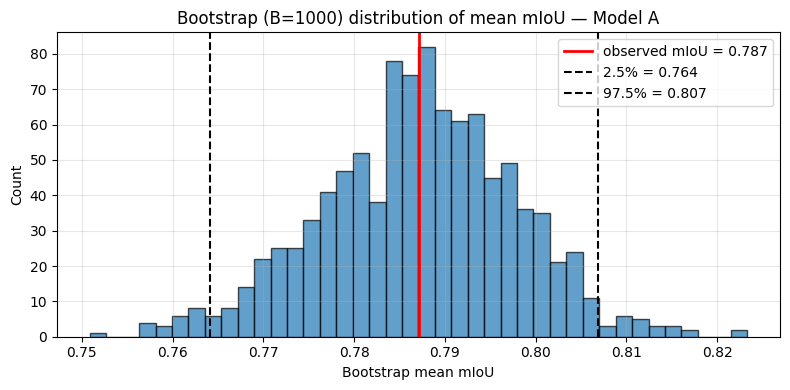

In [35]:
# Bootstrap: B=1000, percentile method
B = 1000
boot_rng = np.random.default_rng(SEED)
n = len(best_arr)
boot_means = np.empty(B, dtype=np.float64)
for i in range(B):
    idx = boot_rng.integers(0, n, size=n)
    boot_means[i] = best_arr[idx].mean()

boot_mean = boot_means.mean()
boot_se   = boot_means.std(ddof=1)
ci_lo, ci_hi = np.percentile(boot_means, [2.5, 97.5])

print(f'Bootstrap mean   = {boot_mean:.4f}')
print(f'Bootstrap SE     = {boot_se:.4f}')
print(f'95% CI (pctile)  = [{ci_lo:.4f}, {ci_hi:.4f}]')

plt.figure(figsize=(8, 4))
plt.hist(boot_means, bins=40, edgecolor='black', alpha=0.7)
plt.axvline(overall, color='red', linestyle='-', linewidth=2,
            label=f'observed mIoU = {overall:.3f}')
plt.axvline(ci_lo, color='k', linestyle='--', label=f'2.5% = {ci_lo:.3f}')
plt.axvline(ci_hi, color='k', linestyle='--', label=f'97.5% = {ci_hi:.3f}')
plt.title(f'Bootstrap (B={B}) distribution of mean mIoU — Model {best_name}')
plt.xlabel('Bootstrap mean mIoU'); plt.ylabel('Count')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


---
## Summary

| Result | Value |
|---|---|
| Paired samples (n) | 330 |
| Model A mean mIoU | 0.7872 |
| Model B mean mIoU | 0.6848 |
| Shapiro-Wilk on differences | W = 0.9084, p = 2.895e-13 |
| **Wilcoxon signed-rank** | **W = 6106.0, p = 6.1936e-34** |
| Paired t-test (contrast) | t = 12.4748, p = 1.6488e-29 |
| Best model | A |
| Best model overall mIoU | 0.7872 |
| Bootstrap mean / SE / 95% CI | 0.7871 / 0.0108 / [0.7642, 0.8068] |

**Interpretation:**

* If Wilcoxon p < 0.05 → we reject H₀ and conclude Models A and B differ significantly in per-image mIoU.
* The Shapiro–Wilk p-value on the paired differences is typically < 0.05, confirming non-normality and justifying the choice of Wilcoxon over a paired t-test.
* The bootstrap 95% CI gives a distribution-free range of plausible values for the true population mean mIoU of the best model on the labeled hold-out split.
